In [45]:
import pandas as pd
import numpy as np

In [46]:
test_df  = pd.read_csv('dataset/cleaned/mini_test_df.csv', sep=',')
train_df = pd.read_csv('dataset/cleaned/mini_train_df.csv', sep=',')


In [47]:
train_df

,Unnamed: 0,features,label
0,14073,[CLS] Acute Transverse Myelitis Secondary to S...,Case Report
1,10206,"[CLS] SARS-CoV-2, More than a Respiratory Viru...",Treatment;Mechanism;Transmission
2,8965,[CLS] Combating COVID-19 and Building Immune R...,Treatment;Prevention;Mechanism
3,24828,[CLS] Automated Assessment of COVID-19 Reporti...,Diagnosis
4,17610,[CLS] Telehealth for Cancer Care in Veterans: ...,Prevention
...,...,...,...
9995,435,[CLS] Analysis of COVID-19 clinical trials: A ...,Treatment
9996,13741,[CLS] A pharmacological interactome between CO...,Treatment;Mechanism
9997,22860,[CLS] Clinical value of the emergency departme...,Diagnosis
9998,7430,[CLS] COVID-19: an update and cardiac involvem...,Treatment;Diagnosis;Mechanism


In [48]:
test_df

,Unnamed: 0,features,label
0,1447,[CLS] Ocular and Systemic Manifestations in Pa...,Diagnosis
1,1114,[CLS] Immunogenicity and safety of the CoronaV...,Treatment
2,1064,[CLS] Walking down the memory lane with SARS-C...,Mechanism;Treatment
3,2287,[CLS] Endoscopic endonasal surgery during COVI...,Prevention
4,1537,[CLS] A closer look at the spreaders of COVID-...,Prevention;Transmission
...,...,...,...
1995,1856,[CLS] Evidencing the influence of pre-pandemic...,Prevention
1996,1388,[CLS] A Rare Case of Herpes Zoster in an Adult...,Case Report
1997,1519,[CLS] Hyperacute reversible encephalopathy rel...,Case Report
1998,1671,[CLS] Forecasting the impact of environmental ...,Transmission


In [49]:
train_df.drop(columns=['Unnamed: 0'], inplace=True)
test_df.drop(columns=['Unnamed: 0'], inplace=True)

print(train_df.columns)
print(test_df.columns)

Index(['features', 'label'], dtype='str')
Index(['features', 'label'], dtype='str')


In [50]:
from transformers import AutoTokenizer, DataCollatorWithPadding
from datasets import Dataset
from sklearn.preprocessing import MultiLabelBinarizer

# Using PubMedBERT since it is specifically trained on medical data
tokenizer = AutoTokenizer.from_pretrained('microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext')

if isinstance(train_df['label'].iloc[0], str):
    train_df['label'] = train_df['label'].str.split(';')

if isinstance(test_df['label'].iloc[0], str):
    test_df['label'] = test_df['label'].str.split(';')

# Multi Hot-Encoding labels since labels may have multiple values
mlb           = MultiLabelBinarizer()
binary_labels = mlb.fit_transform(train_df['label'])

train_df['label'] = list(binary_labels.astype(float))
test_df['label']  = list(mlb.transform(test_df['label']).astype(float))

# Converting pandas df into HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df[['features', 'label']])
test_dataset  = Dataset.from_pandas(test_df[['features', 'label']])

def tokenize_fn(batch):
    return tokenizer(
        batch['features'], 
        truncation=True,
        max_length=512,
        add_special_tokens=False,
    )

train_tokenized_dataset = train_dataset.map(tokenize_fn, batched=True)
test_tokenized_dataset  = test_dataset.map(tokenize_fn, batched=True)

train_tokenized_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_tokenized_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [51]:
train_tokenized_dataset = train_tokenized_dataset.remove_columns(['features'])
test_tokenized_dataset  = test_tokenized_dataset.remove_columns(['features'])

In [52]:
train_tokenized_dataset

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 10000
})

In [53]:
test_tokenized_dataset

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2000
})

In [54]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_tokenized_dataset, 
    shuffle=True,
    batch_size=128,
    collate_fn=data_collator
)

test_loader = DataLoader(
    test_tokenized_dataset,
    batch_size=128,
    collate_fn=data_collator
)

In [55]:
for batch in train_loader:
  for k, v in batch.items():
    print("k:", k, "v.shape:", v.shape)
    print(v)
  break

k: input_ids v.shape: torch.Size([64, 512])
tensor([[    2,  4052,  2644,  ...,     0,     0,     0],
        [    2,  2333,  1930,  ...,     0,     0,     0],
        [    2, 14469,  5799,  ...,     0,     0,     0],
        ...,
        [    2,  4711,  1927,  ...,     0,     0,     0],
        [    2,    43,  3087,  ...,     0,     0,     0],
        [    2,  9571,  1927,  ...,     0,     0,     0]])
k: attention_mask v.shape: torch.Size([64, 512])
tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])
k: labels v.shape: torch.Size([64, 7])
tensor([[0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class Expert(nn.Module):
    '''
    Output = Dropout(Linear(SILU(Linear(x))))
    '''
    def __init__(self, d_model, dropout_prob=0.1):
        super().__init__()
        d_dims = d_model * 2

        self.w1 = nn.Linear(d_model, d_dims, bias=False)
        self.w2 = nn.Linear(d_model, d_dims, bias=False)
        self.w3 = nn.Linear(d_dims, d_model, bias=False)
        
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        gate = F.silu(self.w1(x)) 
        
        value = self.w2(x)
        
        x = gate * value
        
        return self.dropout(self.w3(x))
    

In [57]:
class MoELayer(nn.Module):
    def __init__(self, d_model, num_experts=8, top_k=2, dropout_prob=0.1):
        super().__init__()
        self.num_experts = num_experts
        self.top_k       = top_k
        
        '''
        Shared Expert: All tokens will be routed through this expert
        '''
        self.shared_expert = Expert(d_model, dropout_prob)
        
        '''
        Router: Used to route tokens to the correct expert
            - Note that this model uses top-k + 1 experts where k
        is the number of experts you want to call for each token. It
        is k + 1 because the shared expert is called on each token
        '''
        self.router  = nn.Linear(d_model, num_experts, bias=False)
        self.experts = nn.ModuleList([Expert(d_model, dropout_prob) for _ in range(num_experts)])

    def forward(self, x):
        N, T, D = x.shape
        tokens = x.view(-1, D)
        num_tokens = tokens.size(0)

        # Shared Expert
        shared_out = self.shared_expert(tokens)
        
        # Router Logits with Noise
        logits = self.router(tokens)
        if self.training:
            # Adding noise for exploration
            noise = torch.randn_like(logits) * (1.0 / self.num_experts)
            logits = logits + noise

        probs = F.softmax(logits, dim=-1)
    
        # Get Top-k Logits and Indices
        topk_probs, indices = torch.topk(probs, self.top_k, dim=-1)
        
        # Calculating dot product for each expert
        # for load balancing
        P_i = probs.mean(dim=0)

        f_i = torch.zeros(self.num_experts, device=tokens.device)
        f_i.scatter_add_(0, indices.view(-1), torch.ones(indices.numel(), device=tokens.device))
        f_i = f_i / (num_tokens * self.top_k)

        aux_loss = self.num_experts * torch.sum(f_i * P_i)

        weights = topk_probs / topk_probs.sum(dim=-1, keepdim=True)
        
        routed_out = torch.zeros_like(tokens)
        for i, expert in enumerate(self.experts):
            token_mask, top_k_pos = torch.where(indices == i)
            if token_mask.numel() > 0:
                expert_out = expert(tokens[token_mask])
                gating_weight = weights[token_mask, top_k_pos].unsqueeze(-1)
                routed_out[token_mask] += gating_weight * expert_out

        return (shared_out + routed_out).view(N, T, D), aux_loss

In [58]:
class MultiHeadAttention(nn.Module):
    '''
    Multi-Head Attention Mechanism
    
    Self and Cross attention is supported:
        - Self-Attention: Only pass 'x
        - Cross-Attention: Pass 'x' and context
        where context is the output of the Encoder
    '''
    def __init__(self, d_k, d_model, num_heads):
        super().__init__()

        self.d_k       = d_k
        self.num_heads = num_heads

        # Mapping/Projection for the three attention components
        self.key   = nn.Linear(d_model, d_k * num_heads)
        self.query = nn.Linear(d_model, d_k * num_heads)
        self.value = nn.Linear(d_model, d_k * num_heads)

        # Output Projection: Integrates multihead outputs and restores d_model
        # dimension to support residual connections and attention layer stacking
        self.fc = nn.Linear(d_k * num_heads, d_model)

    def forward(self, x, context=None, mask=None):
        if context is None:
            context = x
        
        q = self.query(x)
        k = self.key(context)
        v = self.value(context)

        N = q.shape[0]
        T = q.shape[1]
        T_ctx = k.shape[1]

        # .view() reshapes a tensor without moving data into memory
        # .transpose changes data (N, T, h, d_k) --> (N, h, T, d_k)
        # This results in matmul shape (N, h, T, d_k) * (N, h, T, d_k) = (N, h, T, T)
        q = q.view(N, T, self.num_heads, self.d_k).transpose(1,2)
        k = k.view(N, T_ctx, self.num_heads, self.d_k).transpose(1,2)
        v = v.view(N, T_ctx, self.num_heads, self.d_k).transpose(1,2)

        # Computes raw attention score with output (N, h, T, T)
        raw_attn_scores = q @ k.transpose(-2,-1) / math.sqrt(self.d_k)

        if mask is not None:
            raw_attn_scores = raw_attn_scores.masked_fill(
                mask[:, None, None, :] == 0, float('-inf')
            )
        attn_weights = nn.functional.softmax(raw_attn_scores, dim=-1)

        # Computes attention weights (N, h, T, T) x (N, h, T, d_k) --> (N, h, T, d_k)
        A = attn_weights @ v

        # Reshapes data back before final Linear Layer (N, T, h, d_k)
        A = A.transpose(1,2)
        # (N, T, h * d_k)
        A = A.contiguous().view(N,T,self.d_k * self.num_heads)

        return self.fc(A)

In [59]:
class TransformerBlock(nn.Module):
    def __init__(self, d_k, d_model, num_heads, dropout_prob=0.1, num_experts=8, top_k=2):
        super().__init__()
        self.ln1     = nn.LayerNorm(d_model)
        self.ln2     = nn.LayerNorm(d_model)
        self.mha     = MultiHeadAttention(d_k, d_model, num_heads)
        self.moe     = MoELayer(
            d_model=d_model, 
            top_k=top_k, 
            dropout_prob=dropout_prob, 
            num_experts=num_experts)
        self.dropout = nn.Dropout(p=dropout_prob)

    def forward(self, x, mask=None):
        x = x + self.mha(self.ln1(x), mask=mask)
        x = self.dropout(x)
        moe_out, aux_loss = self.moe(self.ln2(x))

        x = x + moe_out
        x = self.dropout(x)

        return x, aux_loss

In [60]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=2048, dropout_prob=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout_prob)

        # Extra dimension is added to position to increase
        # the dimensionality of the positional data
        position = torch.arange(max_len).unsqueeze(1)

        # Creates a series with range of number from 0 to 
        # the d_model (dimensonality of word embeddings) with step 2
        # The term is used to frequency for sine and cosine waves
        exp_term = torch.arange(0, d_model, 2)

        # Scaling factor that determines the frequency of 
        # the sine and cosine waves for each dimension
        div_term = torch.exp(exp_term * (-math.log(10000.0) / d_model))

        # Positional Encoding matrix
        pe             = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)

        # register_buffer: register a tensor as part of a module's state, state_dict(), that is not a learnable 
        # parameter so we do not need to manually move it to the correct device using self.pe = pe.to(device)

        # register_buffer saves non-learnable data (data that is not affected by gradient descent)
        # and automatically moves it to device
        self.register_buffer('pe', pe)

    def forward(self, x):
        '''
        Adds Positional Encoding to word embeddings
        '''
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [61]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, max_len, d_k, d_model, num_heads, n_layers, n_classes, dropout_prob, num_experts=8, top_k=2):
        super().__init__()
        self.embedding          = nn.Embedding(vocab_size, d_model)
        self.pos_encoding       = PositionalEncoding(d_model, max_len, dropout_prob)
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(
                d_k=d_k, 
                d_model=d_model, 
                num_heads=num_heads, 
                dropout_prob=dropout_prob, 
                num_experts=num_experts, 
                top_k=top_k) 
            for _ in range(n_layers)
        ])
        self.ln = nn.LayerNorm(d_model)

        self.fc = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.GELU(), 
            nn.Dropout(dropout_prob),
            nn.Linear(d_model * 2, d_model // 2), 
            nn.GELU(),
            nn.Dropout(dropout_prob),
            nn.Linear(d_model // 2, n_classes)
        )

    def forward(self, x, mask=None):
        x = self.embedding(x)
        x = self.pos_encoding(x)

        total_aux_loss = 0
        for block in self.transformer_blocks:
            x, aux_loss = block(x, mask)
            total_aux_loss += aux_loss
        
        # Global pooling (using the first token/CLS representation)
        x = x[:, 0, :]
        x = self.ln(x)
        logits = self.fc(x)

        return logits, total_aux_loss

In [ ]:
from torchmetrics import MetricCollection
from torchmetrics.classification import (
    MultilabelAccuracy,
    MultilabelPrecision,
    MultilabelRecall,
    MultilabelF1Score,
    MultilabelExactMatch,
    MultilabelROC,
    MultilabelPrecisionRecallCurve, 
)

# Metrics are calculated using torchmetrics library
def test(loader, model, device, num_labels=len(mlb.classes_)):
    model.eval()

    metrics = MetricCollection({
        'exact_match'           : MultilabelExactMatch(num_labels=num_labels),
        'accuracy'              : MultilabelAccuracy(num_labels=num_labels, average='macro'),
        'precision_micro'       : MultilabelPrecision(num_labels=num_labels, average='micro'),
        'precision_macro'       : MultilabelPrecision(num_labels=num_labels, average='macro'),
        'recall_micro'          : MultilabelRecall(num_labels=num_labels, average='micro'),
        'recall_macro'          : MultilabelRecall(num_labels=num_labels, average='macro'),
        'f1_micro'              : MultilabelF1Score(num_labels=num_labels, average='micro'),
        'f1_macro'              : MultilabelF1Score(num_labels=num_labels, average='macro')
    }).to(device)

    per_class_metrics = MetricCollection({
        'precision': MultilabelPrecision(num_labels=num_labels, average=None),
        'recall'   : MultilabelRecall(num_labels=num_labels, average=None),
        'f1_score' : MultilabelF1Score(num_labels=num_labels, average=None)
    }).to(device)

    roc_curve = MultilabelROC(num_labels=num_labels).to(device)

    pr_curve = MultilabelPrecisionRecallCurve(num_labels=num_labels).to(device)

    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            batch   = {k: v.to(device) for k, v in batch.items()}
            outputs, _ = model(batch['input_ids'], batch['attention_mask'])

            probs        = torch.sigmoid(outputs)
            predictions  = (probs > 0.30).long()
            labels       = batch['labels'].long()

            all_preds.append(predictions.cpu())
            all_labels.append(labels.cpu())

            metrics.update(predictions, labels)
            per_class_metrics.update(predictions, labels)
            pr_curve.update(probs, labels)
            roc_curve.update(probs, labels)

    results           = metrics.compute()
    per_class_results = per_class_metrics.compute()
    pr_curve_results  = pr_curve.compute()
    roc_curve_results = roc_curve.compute()

    metrics.reset()
    per_class_metrics.reset()
    pr_curve.reset()
    roc_curve.reset()

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return results, per_class_results, pr_curve_results, roc_curve_results, all_preds, all_labels

In [63]:
from datetime import datetime

def train(model, criterion, optimizer, scheduler, train_loader, test_loader, epochs, patience=5, aux_weight=0.01):
    
    # Initializing loss variables
    train_losses = np.zeros(epochs)
    test_losses  = np.zeros(epochs)

    # Early Stopping & Checkpoint variables
    best_test_loss         = float('inf')
    epochs_no_improvements = 0
    best_model_state       = None

    for it in range(epochs):
        model.train()
        t0         = datetime.now()
        train_loss = 0
        n_train    = 0
        train_aux_loss = 0

        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            optimizer.zero_grad()

            # --- MoE Forward Pass ---
            # Your Encoder now returns a tuple: (logits, total_aux_loss)
            outputs, aux_loss = model(batch['input_ids'], batch['attention_mask'])
            
            # Primary Task Loss
            main_loss = criterion(outputs, batch['labels'].float())
            
            # Combined Loss: Task + Weighted Load Balancing
            # This ensures experts are utilized evenly
            total_loss = main_loss + (aux_weight * aux_loss)

            # Backward Pass on the combined loss
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            # We track the total loss for the training curve
            train_loss += total_loss.item() * batch['input_ids'].size(0)
            n_train    += batch['input_ids'].size(0)

            train_aux_loss += aux_loss.item() * batch['input_ids'].size(0)

        train_loss /= n_train

        # Evaluates model after each epoch
        model.eval()
        test_loss = 0
        n_test    = 0

        with torch.no_grad():
            for batch in test_loader:
                batch   = {k: v.to(device) for k, v in batch.items()}
                
                # In validation, we usually only care about the task performance
                # so we ignore the aux_loss returned by the tuple
                outputs, _ = model(batch['input_ids'], batch['attention_mask'])
                
                loss       = criterion(outputs, batch['labels'].float())
                test_loss += loss.item() * batch['input_ids'].size(0)
                n_test    += batch['input_ids'].size(0)

        test_loss /= n_test

        train_losses[it] = train_loss
        test_losses[it]  = test_loss

        scheduler.step(test_loss)

        avg_aux_loss = train_aux_loss / n_train

        dt = datetime.now() - t0
        print(f'Epoch {it+1}/{epochs}, Train Loss: {train_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, AUX Loss: {avg_aux_loss} Duration: {dt}')
        
        # Early Stopping & Checkpoint Logic
        if test_loss < best_test_loss:
            best_test_loss         = test_loss
            epochs_no_improvements = 0
            best_model_state       = model.state_dict().copy()
            torch.save(best_model_state, 'model/moe_transformer4.pt')
        else: 
            epochs_no_improvements += 1

        if epochs_no_improvements >= patience: 
            print(f'EarlyStopping Occurred. Training stopped at epoch {it + 1}')
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("Restored best model weights.")

    return train_losses[:it + 1], test_losses[:it + 1]


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, confusion_matrix, ConfusionMatrixDisplay

def print_metrics(split, results, per_class_results, roc_results, class_names):
    fprs, tprs, _ = roc_results
    auroc_scores = [auc(fprs[i].cpu().numpy(), tprs[i].cpu().numpy()) for i in range(len(class_names))]
    macro_auroc  = sum(auroc_scores) / len(auroc_scores)

    print(f"\n{'='*75}")
    print(f"  {split} Metrics")
    print(f"{'='*75}")
    print(f"  Exact Match : {results['exact_match']:.4f}")
    print(f"  Accuracy    : {results['accuracy']:.4f}")
    print(f"  AUROC       : {macro_auroc:.4f}")
    print(f"{'─'*75}")
    print(f"  {'':22} {'Micro':>10} {'Macro':>8}")
    print(f"  {'Precision':22} {results['precision_micro']:>10.4f} {results['precision_macro']:>8.4f}")
    print(f"  {'Recall':22} {results['recall_micro']:>10.4f} {results['recall_macro']:>8.4f}")
    print(f"  {'F1':22} {results['f1_micro']:>10.4f} {results['f1_macro']:>8.4f}")
    print(f"{'─'*75}")
    print(f"  Per-Class Breakdown:")
    print(f"  {'Class':<22} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUROC':>8}")
    print(f"  {'─'*22} {'─'*10} {'─'*8} {'─'*8} {'─'*8}")
    
    col_width = max(len(c) for c in class_names) + 2

    print(f"  {'Class':<{col_width}} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUROC':>8}")
    for i, classname in enumerate(class_names):
        print(f"  {classname:<{col_width}} "
              f"{per_class_results['precision'][i]:>10.4f} "
              f"{per_class_results['recall'][i]:>8.4f} "
              f"{per_class_results['f1_score'][i]:>8.4f} "
              f"{auroc_scores[i]:>8.4f}")

def plot_pr_curves(pr_curve_results, class_names, split='Test'):
    precision_list, recall_list, _ = pr_curve_results
    
    plt.figure(figsize=(10, 8))
    
    for i, classname in enumerate(class_names):
        p = precision_list[i].cpu().numpy()
        r = recall_list[i].cpu().numpy()
        plt.plot(r, p, label=f'{classname}', alpha=0.6)

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Combined {split} Precision-Recall Curves', fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.tight_layout()
    plt.show()

def plot_auroc_curve(roc_curve_results, class_names, split='Test'):
    fprs, tprs, _ = roc_curve_results  # unpack the 3 lists

    plt.figure(figsize=(12, 8))
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Chance')

    for i, classname in enumerate(class_names):
        fpr = fprs[i].detach().cpu().numpy()
        tpr = tprs[i].detach().cpu().numpy()
        plt.plot(fpr, tpr, alpha=0.7, label=f'{classname}')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Combined {split} ROC Curves', fontweight='bold', fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(all_preds, all_labels, class_names):
    true_indices = [list(row).index(1) if 1 in row else -1 for row in all_labels]
    pred_indices = [list(row).index(1) if 1 in row else -1 for row in all_preds]

    filtered     = [(t, p) for t, p in zip(true_indices, pred_indices) if t != -1]
    true_indices, pred_indices = zip(*filtered)

    cm   = confusion_matrix(true_indices, pred_indices, labels=list(range(len(class_names))))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(class_names))

    fig, ax = plt.subplots(figsize=(14, 12))
    disp.plot(ax=ax, colorbar=True, xticks_rotation=45, cmap=plt.cm.Blues)
    plt.title('Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()

In [66]:
model = Encoder(
    vocab_size=tokenizer.vocab_size, 
    max_len=512,
    d_k=64,
    d_model=768,
    num_heads=12,
    dropout_prob=0.1,
    n_layers=8,
    n_classes=len(mlb.classes_),
    num_experts=32, 
    top_k=3
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Setting loss and optimizer
# BCEWithLogitsLoss is used to compute all class labels 
# independently for Multi-class Classification

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.005, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=1, factor=0.65)

model.to(device)

train(model, criterion, optimizer, scheduler, train_loader, test_loader, patience=5, epochs=20)

cuda
Epoch 1/20, Train Loss: 0.4826, Test Loss: 0.4426, AUX Loss: 8.318041804504395 Duration: 0:02:30.982306
Epoch 2/20, Train Loss: 0.4369, Test Loss: 0.4205, AUX Loss: 8.697427870178222 Duration: 0:02:30.946301
Epoch 3/20, Train Loss: 0.3894, Test Loss: 0.3526, AUX Loss: 8.447918322753907 Duration: 0:02:31.329926
Epoch 4/20, Train Loss: 0.3576, Test Loss: 0.3878, AUX Loss: 8.317269105529785 Duration: 0:02:31.568376
Epoch 5/20, Train Loss: 0.3383, Test Loss: 0.3154, AUX Loss: 8.255150286865234 Duration: 0:02:31.725608
Epoch 6/20, Train Loss: 0.3130, Test Loss: 0.3118, AUX Loss: 8.320400302124023 Duration: 0:02:31.392037
Epoch 7/20, Train Loss: 0.2992, Test Loss: 0.3176, AUX Loss: 8.378302461242676 Duration: 0:02:31.849825
Epoch 8/20, Train Loss: 0.2880, Test Loss: 0.2770, AUX Loss: 8.339246090698243 Duration: 0:02:31.669079
Epoch 9/20, Train Loss: 0.2774, Test Loss: 0.2866, AUX Loss: 8.250895492553711 Duration: 0:02:31.889086
Epoch 10/20, Train Loss: 0.2742, Test Loss: 0.2655, AUX Los

(array([0.48258934, 0.43694234, 0.38942253, 0.35759193, 0.33831906,
        0.31300702, 0.29918081, 0.28795039, 0.27744079, 0.27424649,
        0.26622419, 0.25939854, 0.24266374, 0.23190664, 0.2280669 ,
        0.22153012, 0.21609056, 0.21404711, 0.21078461, 0.19927296]),
 array([0.44259681, 0.4204976 , 0.35255061, 0.38784887, 0.31536834,
        0.31182169, 0.31761578, 0.27700107, 0.28658483, 0.26549938,
        0.2718365 , 0.32350942, 0.26483231, 0.27618869, 0.26308937,
        0.28906933, 0.25418677, 0.28389366, 0.31358578, 0.29375228]))

In [67]:
# Get the first MoE layer's experts
first_moe = model.transformer_blocks[0].moe

expert_params    = sum(p.numel() for p in first_moe.experts[0].parameters())
shared_params    = sum(p.numel() for p in first_moe.shared_expert.parameters())
active_per_token = shared_params + (expert_params * model.transformer_blocks[0].moe.top_k)
total_params = sum(p.numel() for p in model.parameters())

print(f"Total parameters: {total_params:,}")
print(f"Expert params:       {expert_params:,}")
print(f"Shared params:       {shared_params:,}")
print(f"Active per token:    {active_per_token:,}  (shared + top_{first_moe.top_k} experts)")
print(f"Total expert params: {expert_params * first_moe.num_experts:,}")

Total parameters: 978,617,863
Expert params:       3,538,944
Shared params:       3,538,944
Active per token:    14,155,776  (shared + top_3 experts)
Total expert params: 113,246,208



  Test Metrics
  Exact Match : 0.6285
  Accuracy    : 0.9169
  AUROC       : 0.9482
───────────────────────────────────────────────────────────────────────────
                              Micro    Macro
  Precision                  0.7816   0.7517
  Recall                     0.8309   0.7281
  F1                         0.8055   0.7349
───────────────────────────────────────────────────────────────────────────
  Per-Class Breakdown:
  Class                   Precision   Recall       F1    AUROC
  ────────────────────── ────────── ──────── ──────── ────────
  Class                   Precision   Recall       F1    AUROC
  Case Report                0.9016   0.6707   0.7692   0.9688
  Diagnosis                  0.7311   0.7923   0.7605   0.9201
  Epidemic Forecasting       0.6538   0.5000   0.5667   0.9642
  Mechanism                  0.7924   0.7667   0.7794   0.9535
  Prevention                 0.8289   0.9127   0.8688   0.9669
  Transmission               0.5743   0.5524   0.5631   

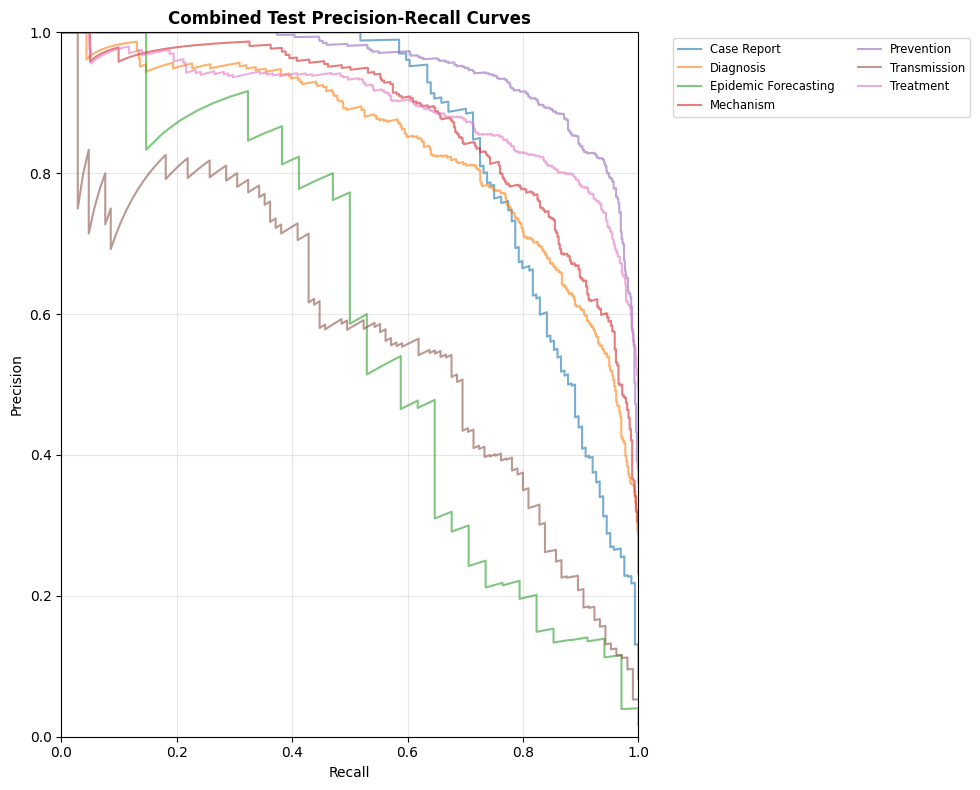

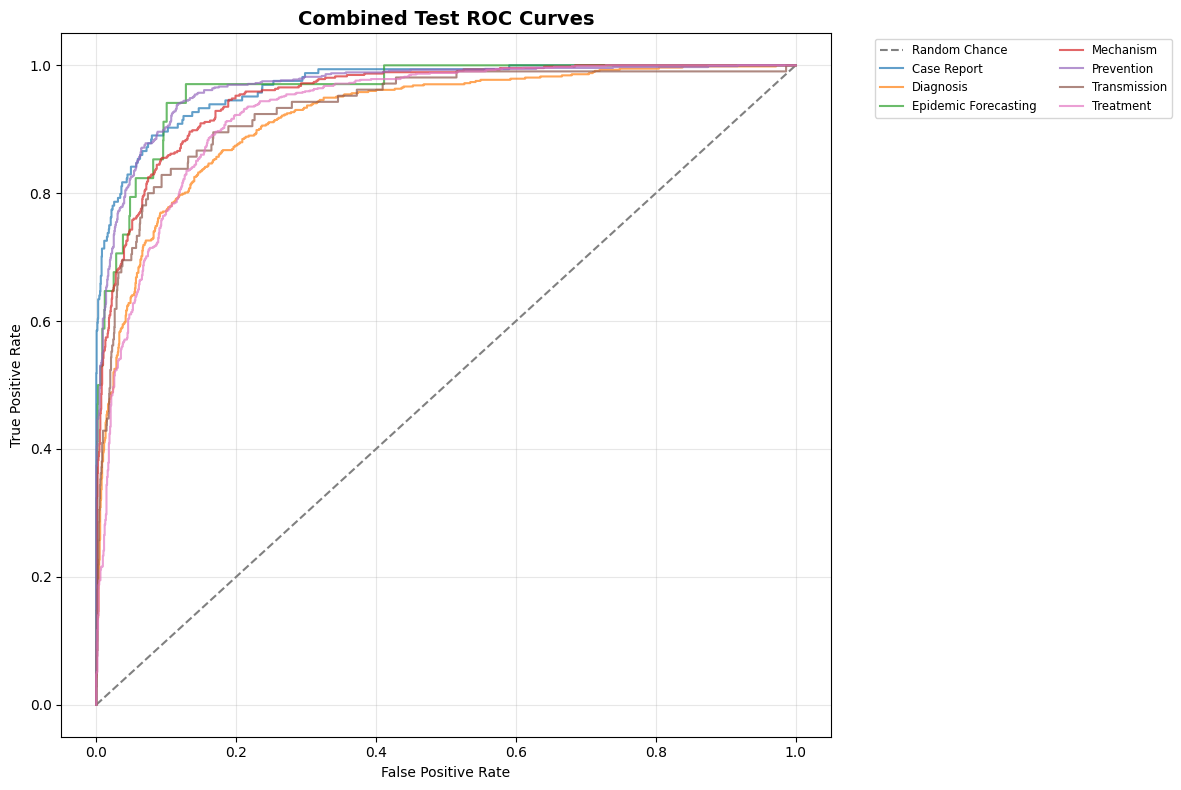

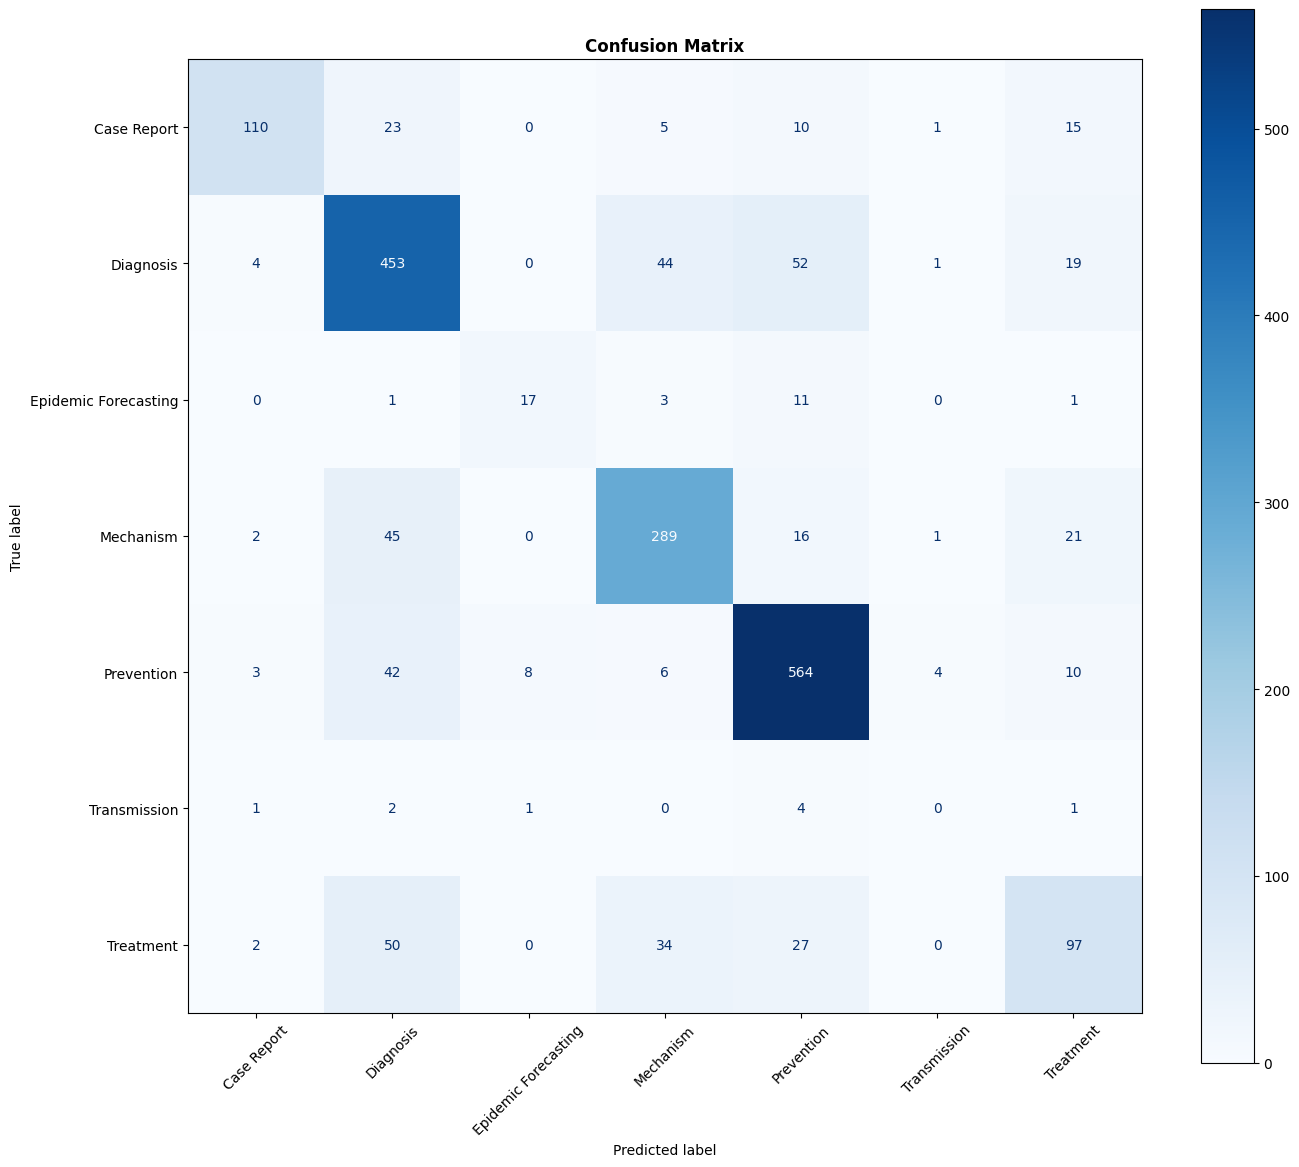

In [71]:
# train_results, train_per_class, train_pr_curve, train_roc = test(train_loader, model, device)
test_results, test_per_class, test_pr_curve, test_roc, all_preds, all_labels = test(test_loader, model, device)

# Print
# print_metrics('Train', train_results, train_per_class, train_roc, mlb.classes_)
print_metrics('Test',  test_results,  test_per_class, test_roc, mlb.classes_)

# Plot
# plot_pr_curves(train_pr_curve, mlb.classes_, split='Train')
plot_pr_curves(test_pr_curve,  mlb.classes_, split='Test')

# plot_auroc_curve(train_roc, mlb.classes_, split='Train')
plot_auroc_curve(test_roc, mlb.classes_, split='Test')

plot_confusion_matrix(all_preds, all_labels, list(mlb.classes_))